In [15]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import os

In [16]:
def graph_to_matrix(graph):
    nodes = list(graph.nodes)
    matrix = np.zeros((len(nodes), len(nodes)))
    for i, node_i in enumerate(nodes):
        for j, node_j in enumerate(nodes):
            if node_i in graph and node_j in graph[node_i]:
                matrix[i, j] = 1  # assuming unweighted edges
    return matrix

In [17]:
folder_path = '/workspaces/ESN-unofficial/data/folder_path_83'
#folder_path=('C:\\Users\\user\\OneDrive\\università\\BAINSA\\ESN\\network_architecture\\folder_path_83')

In [18]:
# read all .graphml files from the folder
# parse them into graph objects using the networkx library
# store these graphs in a list

graphml_files = [f for f in os.listdir(folder_path) if f.endswith('.graphml')]
graphs = []
for file in graphml_files:
    file_path = os.path.join(folder_path, file)
    graph = nx.read_graphml(file_path)
    graphs.append(graph)

In [19]:
graphs

 ...]

In [20]:
for i, graph in enumerate(graphs):
    print(f"Graph {i+1}: Nodes={graph.number_of_nodes()}, Edges={graph.number_of_edges()}")

Graph 1: Nodes=83, Edges=730
Graph 2: Nodes=83, Edges=804
Graph 3: Nodes=83, Edges=737
Graph 4: Nodes=83, Edges=839
Graph 5: Nodes=83, Edges=758
Graph 6: Nodes=83, Edges=746
Graph 7: Nodes=83, Edges=852
Graph 8: Nodes=83, Edges=793
Graph 9: Nodes=83, Edges=733
Graph 10: Nodes=83, Edges=722
Graph 11: Nodes=83, Edges=677
Graph 12: Nodes=83, Edges=634
Graph 13: Nodes=83, Edges=804
Graph 14: Nodes=83, Edges=748
Graph 15: Nodes=83, Edges=868
Graph 16: Nodes=83, Edges=895
Graph 17: Nodes=83, Edges=826
Graph 18: Nodes=83, Edges=815
Graph 19: Nodes=83, Edges=782
Graph 20: Nodes=83, Edges=718
Graph 21: Nodes=83, Edges=667
Graph 22: Nodes=83, Edges=891
Graph 23: Nodes=83, Edges=543
Graph 24: Nodes=83, Edges=776
Graph 25: Nodes=83, Edges=660
Graph 26: Nodes=83, Edges=700
Graph 27: Nodes=83, Edges=903
Graph 28: Nodes=83, Edges=765
Graph 29: Nodes=83, Edges=926
Graph 30: Nodes=83, Edges=775
Graph 31: Nodes=83, Edges=718
Graph 32: Nodes=83, Edges=821
Graph 33: Nodes=83, Edges=868
Graph 34: Nodes=83,

In [21]:
# convert graphs to matrices and average them
# averaging, so creating a single representative graph that captures common features across all the individual graphs
# why? to capture patterns, reduce noise, and simplify

matrices = [graph_to_matrix(graph) for graph in graphs]
average_matrix = np.mean(matrices, axis=0)

In [22]:
# parameters
N = 83  # no. of nodes
J = 1.0  # scaling factor
dt = 0.01  # time step
T = 100  # total time
time_steps = int(T / dt)
p = 0.1  # connection probability

In [23]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x)) - 0.5

def euler_method(r, A, dt, J):
    inputs = np.dot(A, r)
    return r + dt * (-r + sigmoid(inputs))

def compute_mean_firing_rate(rates):
    return np.mean(rates, axis=1)

def compute_variance_firing_rate(rates):
    return np.var(rates, axis=1)

In [24]:
# network architectures

# fully connected network (all nodes connected with equal weight)
A_fully_connected = np.ones((N, N)) * J / N

# Erdos-Renyi network (connections are random w.p. p)
k = p * N
A_erdos_renyi = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        if np.random.rand() < p:
            A_erdos_renyi[i, j] = J / k

# Gaussian random network (each weight drawn from a Gaussian distribution)
A_gaussian_random = np.random.normal(0, J**2 / N, size=(N, N))

# data network (uses average matrix derived from connectome data on https://braingraph.org/cms/download-pit-group-connectomes/)
A_data_network = average_matrix

In [25]:
# initialise rates for all networks
initial_rates = np.random.uniform(0, 1, N)

# firing rate evolution is simulated using the Euler method for each type of network

# simulate dynamics for fully connected network
rates_fully_connected = np.zeros((time_steps, N))
r = initial_rates.copy()
for t in range(time_steps):
    rates_fully_connected[t] = r
    r = euler_method(r, A_fully_connected, dt, J)

mean_firing_rate_fully_connected = compute_mean_firing_rate(rates_fully_connected)
variance_firing_rate_fully_connected = compute_variance_firing_rate(rates_fully_connected)

# simulate dynamics for Erdos-Renyi network
rates_erdos_renyi = np.zeros((time_steps, N))
r = initial_rates.copy()
for t in range(time_steps):
    rates_erdos_renyi[t] = r
    r = euler_method(r, A_erdos_renyi, dt, J)

mean_firing_rate_erdos_renyi = compute_mean_firing_rate(rates_erdos_renyi)
variance_firing_rate_erdos_renyi = compute_variance_firing_rate(rates_erdos_renyi)

# simulate dynamics for Gaussian random network
rates_gaussian_random = np.zeros((time_steps, N))
r = initial_rates.copy()
for t in range(time_steps):
    rates_gaussian_random[t] = r
    r = euler_method(r, A_gaussian_random, dt, J)

mean_firing_rate_gaussian_random = compute_mean_firing_rate(rates_gaussian_random)
variance_firing_rate_gaussian_random = compute_variance_firing_rate(rates_gaussian_random)

# simulate dynamics for Data network
rates_data_network = np.zeros((time_steps, N))
r = initial_rates.copy()
for t in range(time_steps):
    rates_data_network[t] = r
    r = euler_method(r, A_data_network, dt, J)

mean_firing_rate_data_network = compute_mean_firing_rate(rates_data_network)
variance_firing_rate_data_network = compute_variance_firing_rate(rates_data_network)

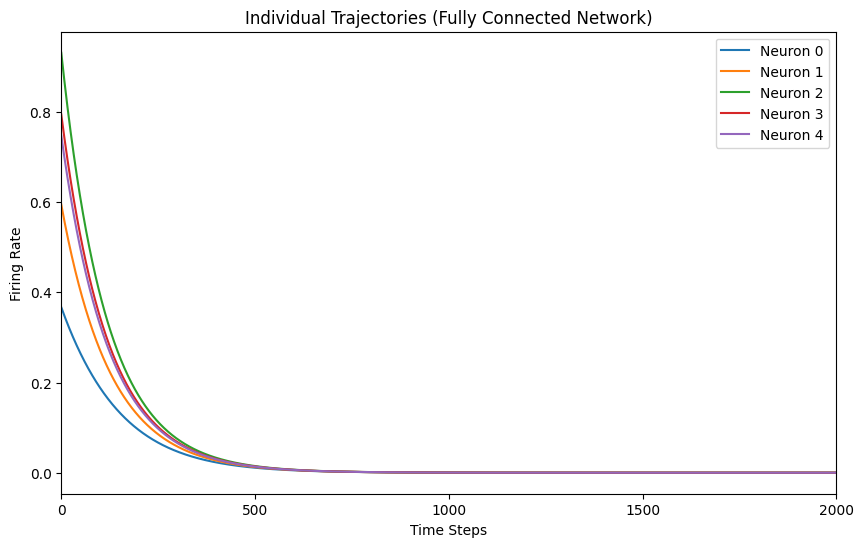

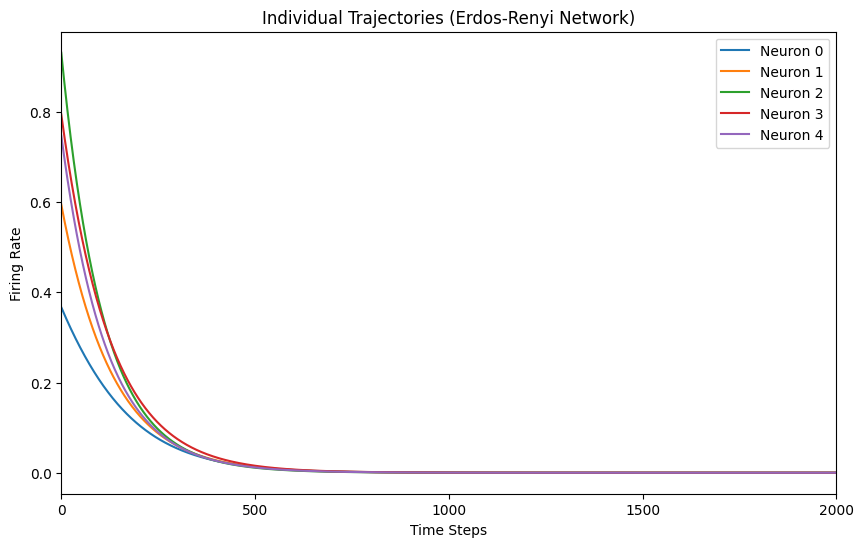

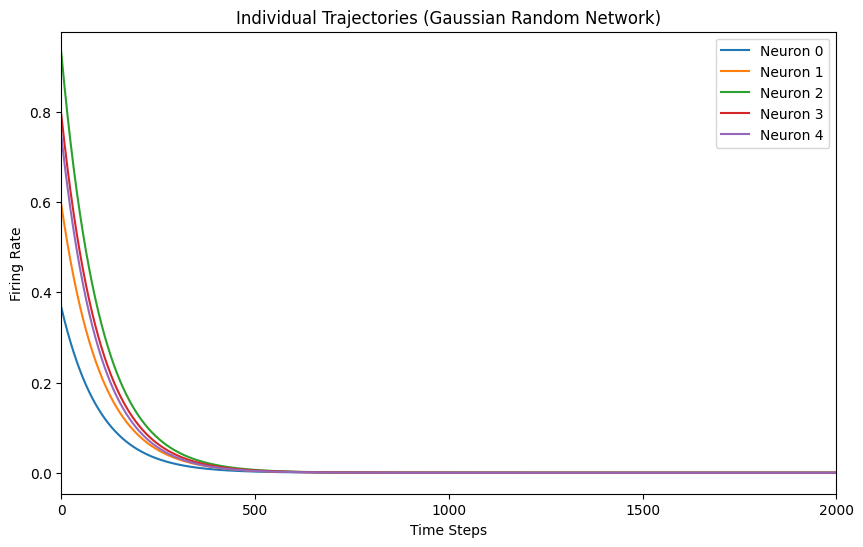

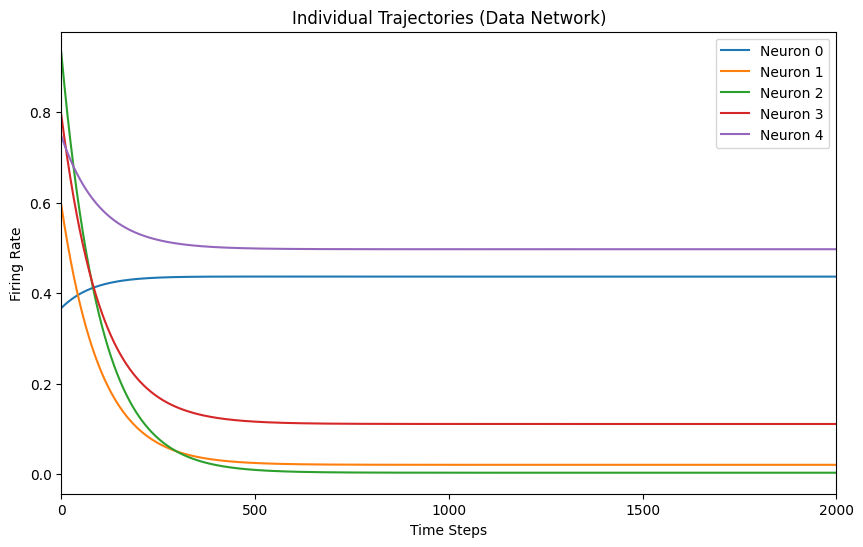

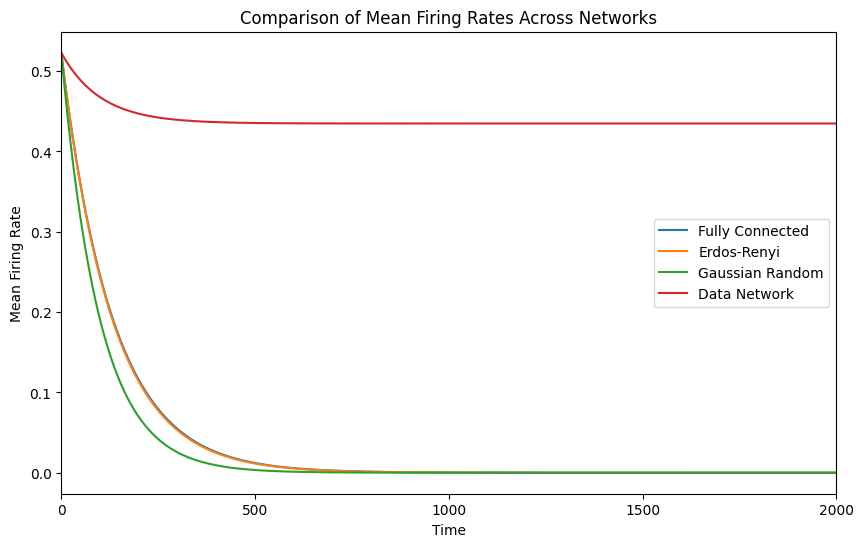

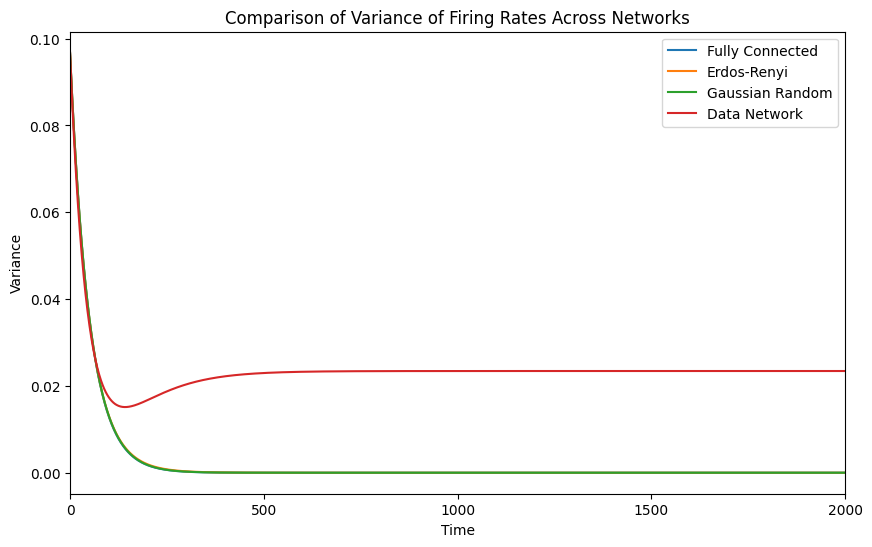

In [26]:
# plot individual trajectories for each network type (firing rate evolution for each neuron over time)
networks = {
    "Fully Connected Network": rates_fully_connected,
    "Erdos-Renyi Network": rates_erdos_renyi,
    "Gaussian Random Network": rates_gaussian_random,
    "Data Network": rates_data_network,
}

for name, rates in networks.items():
    plt.figure(figsize=(10, 6))
    for i in range(min(5, rates.shape[1])):  # labels for first 5 neurons
        plt.plot(rates[:, i], label=f'Neuron {i}')
    plt.title(f'Individual Trajectories ({name})')
    plt.xlabel('Time Steps')
    plt.ylabel('Firing Rate')
    plt.legend()
    plt.xlim(0, 2000)  # limit to 2000 time steps
    plt.xticks(np.arange(0, 2001, 500))
    plt.show()

# compare how different network topologies affect the system's behaviour

# compare mean firing rates across networks
plt.figure(figsize=(10, 6))
plt.plot(mean_firing_rate_fully_connected, label='Fully Connected')
plt.plot(mean_firing_rate_erdos_renyi, label='Erdos-Renyi')
plt.plot(mean_firing_rate_gaussian_random, label='Gaussian Random')
plt.plot(mean_firing_rate_data_network, label='Data Network')
plt.title('Comparison of Mean Firing Rates Across Networks')
plt.xlabel('Time')
plt.ylabel('Mean Firing Rate')
plt.xlim(0, 2000)
plt.xticks(np.arange(0, 2001, 500))
plt.legend()
plt.show()

# compare variance of firing rates across networks
plt.figure(figsize=(10, 6))
plt.plot(variance_firing_rate_fully_connected, label='Fully Connected')
plt.plot(variance_firing_rate_erdos_renyi, label='Erdos-Renyi')
plt.plot(variance_firing_rate_gaussian_random, label='Gaussian Random')
plt.plot(variance_firing_rate_data_network, label='Data Network')
plt.title('Comparison of Variance of Firing Rates Across Networks')
plt.xlabel('Time')
plt.ylabel('Variance')
plt.xlim(0, 2000)
plt.xticks(np.arange(0, 2001, 500))
plt.legend()
plt.show()

In [27]:
#have to do it like this since J changes
# Network types
def create_fully_connected_network(J):
    return np.ones((N, N)) * J / N

def create_erdos_renyi_network(J):
    k = p * N
    A = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            if np.random.rand() < p:
                A[i, j] = J / k
    return A

def create_gaussian_random_network(J):
    return np.random.normal(0, J**2 / N, size=(N, N))

def create_data_network(J):
    return average_matrix * J

In [ ]:
# Parameters
N = 83  # Number of neurons
n_trials = 1000  # Number of trials for averaging
J_values = np.linspace(0, 8, 20)  # Range of J values
T=10


network_creators = {
    "Fully Connected": create_fully_connected_network,
    "Erdos-Renyi": create_erdos_renyi_network,
    "Gaussian Random": create_gaussian_random_network,
    "Data Network": create_data_network,
}

# Storage for results
results = {network_name: {"mean_activity": [], "var_activity": []} for network_name in network_creators.keys()}

# Iterate over network types and J values
for network_name, create_network in network_creators.items():
    for J in J_values:
        trial_means = []
        trial_vars = []

        for _ in range(n_trials):
            # Create the network adjacency matrix
            A = create_network(J)

            # Initialize rates
            r = np.random.uniform(0, 1, N)
            rates = np.zeros((time_steps, N))

            # Simulate dynamics
            for t in range(time_steps):
                rates[t] = r
                r = euler_method(r, A, dt, J)

            # Compute mean and variance at the final time step
            trial_means.append(np.mean(rates[-1]))
            trial_vars.append(np.var(rates[-1]))

        # Average over trials
        results[network_name]["mean_activity"].append(np.mean(trial_means))
        results[network_name]["var_activity"].append(np.mean(trial_vars))

# Plotting results
for network_name in network_creators.keys():
    mean_activity = results[network_name]["mean_activity"]
    var_activity = results[network_name]["var_activity"]

    plt.figure(figsize=(12, 5))

    # Mean activity vs J
    plt.subplot(1, 2, 1)
    plt.plot(J_values, mean_activity, marker='o')
    plt.title(f'Mean Activity vs J ({network_name})')
    plt.xlabel('J (Scaling Factor)')
    plt.ylabel('Mean Activity')

    # Variance vs J
    plt.subplot(1, 2, 2)
    plt.plot(J_values, var_activity, marker='o', color='r')
    plt.title(f'Variance vs J ({network_name})')
    plt.xlabel('J (Scaling Factor)')
    plt.ylabel('Variance')

    plt.tight_layout()
    plt.show()